# Bootstrap Analysis for Self-Prioritization Effect in Mismatch Conditions

**Objective**: Compute self-prioritization effect (Self vs. Stranger) in mismatch conditions with bootstrap resampling and sequential sample size augmentation.

**Method**:
1. Load all *_Clean.csv files from 1_Data directory
2. Filter for mismatch (Nonmatching) trials only
3. Calculate Cohen's d (Stranger-Self) per participant
4. Perform bootstrap resampling with sequential sample size augmentation
5. Generate 4 figures showing effect size vs sample size with 95% CI

**Data Filtering**:
- **Strict filtering (Figures 1-2)**: Requires both Shape and Label information, plus a third social identity to control for self-relevance
- **Loose filtering (Figures 3-4)**: Only requires Shape to be Self or Stranger, no Label filtering needed

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Define paths
data_path = Path("D:/GitHub_programe/GitHub/SPE_Database/1_Data")
output_path = Path("D:/GitHub_programe/GitHub/SPE_Database/3_Reports/Bootstrap")
output_path.mkdir(exist_ok=True)

# Find all Clean.csv files
clean_files = list(data_path.rglob("*_Clean.csv"))
print(f"Found {len(clean_files)} Clean.csv files")
for f in clean_files[:5]:  # Show first 5
    print(f"  - {f.relative_to(data_path)}")

Found 72 Clean.csv files
  - Amodeo_2024_CABN\Amodeo_2024_CABN_Exp1_Clean.csv
  - Constable_2020_AP\Constable_2020_AP_Exp1_Clean.csv
  - Feldborg_2021_ERPH\Feldborg_2021_ERPH_Exp1_Clean.csv
  - Haciahmet_2023_Psy\Haciahmet_2023_Psy_Exp1_Clean.csv
  - Hobbs_2023_PM\Hobbs_2023_PM_Exp1_Clean.csv


In [3]:
# Load and merge all Clean.csv files
all_data = []

for file_path in clean_files:
    try:
        df = pd.read_csv(file_path)
        # Add source file identifier
        df['Source'] = file_path.stem
        all_data.append(df)
        print(f"Loaded: {file_path.name} - {len(df)} rows")
    except Exception as e:
        print(f"Error loading {file_path.name}: {e}")

# Merge all dataframes
merged_df = pd.concat(all_data, ignore_index=True)
print(f"\nTotal merged data: {len(merged_df)} rows")
print(f"Columns: {list(merged_df.columns)}")
print(f"\nData sample:")
merged_df.head()

Loaded: Amodeo_2024_CABN_Exp1_Clean.csv - 24120 rows
Loaded: Constable_2020_AP_Exp1_Clean.csv - 22080 rows
Loaded: Feldborg_2021_ERPH_Exp1_Clean.csv - 32640 rows
Loaded: Haciahmet_2023_Psy_Exp1_Clean.csv - 10560 rows
Loaded: Hobbs_2023_PM_Exp1_Clean.csv - 0 rows
Loaded: Hu_2020_CP_Exp1_Clean.csv - 25920 rows
Loaded: Hu_2023_Exp1_Clean.csv - 35070 rows
Loaded: Kolvoort_2020_HBM_Exp1_Clean.csv - 11051 rows
Loaded: Liang_2022_HBM_Exp1.1_Clean.csv - 25382 rows
Loaded: Liang_2022_HBM_Exp1.2_Clean.csv - 26082 rows
Loaded: Liang_2022_HBM_Exp1.3_Clean.csv - 26594 rows
Loaded: Liang_2022_HBM_Exp1_Clean.csv - 25382 rows
Loaded: Liu_2023_CP_Exp1_Clean.csv - 19136 rows
Loaded: Martinez-Perez_2024_CC_Exp2_Clean.csv - 7680 rows
Loaded: Mcivor_2020_EJN_Exp1_Clean.csv - 38880 rows
Loaded: Pan_2025_Exp1_Clean.csv - 28037 rows
Loaded: Perrykkad_2022_BMC_Exp1_Clean.csv - 120240 rows
Loaded: Smith_2024_Cortex_Exp1_Clean.csv - 17280 rows
Loaded: Sui_2014_Exp1_Clean.csv - 17280 rows
Loaded: Sui_2023_CC_Exp1

,Subject,Block,Trial,Shape,Label,Matching,Label_Origin_Identity,Label_English_Identity,Label_Standardized_Identity,Shape_Origin_Identity,...,Voice,Mood,Arouse,Unnamed: 0,Identity,Symmetry,Face_Gender,Label1,Label2,Label3
0,2,1.0,1.0,T.bmp,Vreemde,Matching,Vreemde,Stranger,Stranger,Stranger,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1.0,2.0,S.bmp,Ikzelf,Matching,Ikzelf,Self,Self,Self,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1.0,3.0,C.bmp,Bekende,Matching,Bekende,Friend,Friend,Friend,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,1.0,4.0,S.bmp,Bekende,Nonmatching,Bekende,Friend,Friend,Self,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,1.0,5.0,T.bmp,Ikzelf,Nonmatching,Ikzelf,Self,Self,Stranger,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Check column names and data types
print("=== Column Information ===")
print(merged_df.dtypes)
print(f"\n=== Unique Matching values ===")
print(merged_df['Matching'].unique())
print(f"\n=== Unique Shape_Standardized_Identity values ===")
print(merged_df['Shape_Standardized_Identity'].unique())
print(f"\n=== Unique Label_Standardized_Identity values ===")
if 'Label_Standardized_Identity' in merged_df.columns:
    print(merged_df['Label_Standardized_Identity'].unique())
else:
    print("Column not found in all datasets")

=== Column Information ===
Subject                         object
Block                          float64
Trial                          float64
Shape                           object
Label                           object
Matching                        object
Label_Origin_Identity           object
Label_English_Identity          object
Label_Standardized_Identity     object
Shape_Origin_Identity           object
Shape_English_Identity          object
Shape_Standardized_Identity     object
Response                        object
RT_ms                          float64
RT_sec                         float64
ACC                            float64
Source                          object
StrangerShape                   object
P1Shape                         object
P2Shape                         object
ShapeLoc                        object
Phase                           object
Group                           object
Condition                       object
Bin                            float6

In [5]:
# Filter for Nonmatching trials only
mismatch_df = merged_df[merged_df['Matching'] == 'Nonmatching'].copy()
print(f"Mismatch trials: {len(mismatch_df)} rows")
print(f"Unique participants: {mismatch_df['Subject'].nunique()}")

# Check RT and ACC
print(f"\n=== RT Statistics ===")
print(mismatch_df['RT_ms'].describe())
print(f"\n=== ACC Statistics ===")
print(mismatch_df['ACC'].describe())

Mismatch trials: 853015 rows
Unique participants: 1676

=== RT Statistics ===
count    7.776590e+05
mean     2.014309e+05
std      2.922190e+07
min     -2.000000e+00
25%      5.335152e+02
50%      7.050000e+02
75%      8.560000e+02
max      4.294967e+09
Name: RT_ms, dtype: float64

=== ACC Statistics ===
count    780246.000000
mean          0.784595
std           0.429804
min          -1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: ACC, dtype: float64


In [6]:
# Define function to calculate Cohen's d
def cohens_d(group1, group2):
    """
    Calculate Cohen's d between two groups.
    d = (mean1 - mean2) / pooled_sd
    """
    n1, n2 = len(group1), len(group2)
    if n1 < 2 or n2 < 2:
        return np.nan
    
    mean1, mean2 = np.mean(group1), np.mean(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    
    # Pooled standard deviation
    pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    
    if pooled_sd == 0:
        return np.nan
    
    return (mean1 - mean2) / pooled_sd

print("Cohen's d function defined successfully!")

Cohen's d function defined successfully!


In [7]:
# STRICT FILTERING: Calculate Cohen's d for Shape baseline
# Requires: Both Shape and Label information, plus third identity for control

def calculate_strict_cohens_d(df, baseline='Shape'):
    """
    Calculate Cohen's d with strict filtering.
    - Requires both Shape and Label standardized identity columns
    - Excludes cases where Shape=Stranger and Label=Self (controlling for self-relevance)
    - Requires at least 3 different identities per participant
    """
    results = []
    
    # Group by participant
    for (source, subject), subj_df in df.groupby(['Source', 'Subject']):
        
        # Check if we have both Shape and Label columns
        if 'Shape_Standardized_Identity' not in subj_df.columns:
            continue
        if 'Label_Standardized_Identity' not in subj_df.columns:
            continue
        
        # Get unique identities
        shape_identities = set(subj_df['Shape_Standardized_Identity'].dropna().unique())
        label_identities = set(subj_df['Label_Standardized_Identity'].dropna().unique())
        
        # Require at least 3 different identities
        if len(shape_identities) < 3 or len(label_identities) < 3:
            continue
        
        # Filter based on baseline
        if baseline == 'Shape':
            # Exclude trials where Shape=Stranger and Label=Self
            filtered = subj_df[
                ~((subj_df['Shape_Standardized_Identity'] == 'Stranger') & 
                  (subj_df['Label_Standardized_Identity'] == 'Self'))
            ]
            identity_col = 'Shape_Standardized_Identity'
        else:  # Label baseline
            # Exclude trials where Label=Stranger and Shape=Self
            filtered = subj_df[
                ~((subj_df['Label_Standardized_Identity'] == 'Stranger') & 
                  (subj_df['Shape_Standardized_Identity'] == 'Self'))
            ]
            identity_col = 'Label_Standardized_Identity'
        
        # Get RT for Self and Stranger
        self_rt = filtered[filtered[identity_col] == 'Self']['RT_ms'].values
        stranger_rt = filtered[filtered[identity_col] == 'Stranger']['RT_ms'].values
        
        # Calculate Cohen's d
        d = cohens_d(stranger_rt, self_rt)
        
        if not np.isnan(d):
            results.append({
                'Source': source,
                'Subject': subject,
                'Baseline': baseline,
                'Filtering': 'Strict',
                'Cohens_d': d,
                'n_Self': len(self_rt),
                'n_Stranger': len(stranger_rt)
            })
    
    return pd.DataFrame(results)

# Calculate strict filtering for Shape and Label
strict_shape = calculate_strict_cohens_d(mismatch_df, baseline='Shape')
strict_label = calculate_strict_cohens_d(mismatch_df, baseline='Label')

print(f"Strict filtering - Shape: {len(strict_shape)} participants")
print(f"Strict filtering - Label: {len(strict_label)} participants")

Strict filtering - Shape: 801 participants
Strict filtering - Label: 801 participants


In [8]:
# LOOSE FILTERING: Calculate Cohen's d for Shape baseline
# Only requires Shape to be Self or Stranger, no Label filtering

def calculate_loose_cohens_d(df, baseline='Shape'):
    """
    Calculate Cohen's d with loose filtering.
    - Only requires Shape to be Self or Stranger
    - No need to control for Label=Self when Shape=Stranger
    """
    results = []
    
    # Group by participant
    for (source, subject), subj_df in df.groupby(['Source', 'Subject']):
        
        # Check if we have Shape column
        if 'Shape_Standardized_Identity' not in subj_df.columns:
            continue
        
        # Filter based on baseline
        if baseline == 'Shape':
            identity_col = 'Shape_Standardized_Identity'
        else:  # Label baseline
            if 'Label_Standardized_Identity' not in subj_df.columns:
                continue
            identity_col = 'Label_Standardized_Identity'
        
        # Get RT for Self and Stranger
        self_rt = subj_df[subj_df[identity_col] == 'Self']['RT_ms'].values
        stranger_rt = subj_df[subj_df[identity_col] == 'Stranger']['RT_ms'].values
        
        # Calculate Cohen's d
        d = cohens_d(stranger_rt, self_rt)
        
        if not np.isnan(d):
            results.append({
                'Source': source,
                'Subject': subject,
                'Baseline': baseline,
                'Filtering': 'Loose',
                'Cohens_d': d,
                'n_Self': len(self_rt),
                'n_Stranger': len(stranger_rt)
            })
    
    return pd.DataFrame(results)

# Calculate loose filtering for Shape and Label
loose_shape = calculate_loose_cohens_d(mismatch_df, baseline='Shape')
loose_label = calculate_loose_cohens_d(mismatch_df, baseline='Label')

print(f"Loose filtering - Shape: {len(loose_shape)} participants")
print(f"Loose filtering - Label: {len(loose_label)} participants")

Loose filtering - Shape: 2074 participants
Loose filtering - Label: 1441 participants


In [9]:
# Combine all Cohen's d results
all_cohens_d = pd.concat([strict_shape, strict_label, loose_shape, loose_label], 
                         ignore_index=True)

# Save to CSV
all_cohens_d.to_csv(output_path / 'cohens_d_by_participant.csv', index=False)

print(f"Total participants with Cohen's d: {len(all_cohens_d)}")
print(f"\n=== Summary Statistics ===")
print(all_cohens_d.groupby(['Filtering', 'Baseline'])['Cohens_d'].describe())

Total participants with Cohen's d: 5117

=== Summary Statistics ===
                     count      mean       std       min       25%       50%  \
Filtering Baseline                                                             
Loose     Label     1441.0  0.086918  0.306751 -1.197952 -0.098357  0.082902   
          Shape     2074.0  0.028551  0.318805 -1.300205 -0.171028  0.015652   
Strict    Label      801.0  0.212299  0.377841 -0.893654 -0.038818  0.196088   
          Shape      801.0  0.125303  0.362970 -1.109424 -0.079968  0.095890   

                         75%       max  
Filtering Baseline                      
Loose     Label     0.276846  1.480794  
          Shape     0.218901  1.460256  
Strict    Label     0.438296  2.506063  
          Shape     0.302695  1.691434  


In [10]:
# Bootstrap resampling with sequential sample size augmentation
def bootstrap_sequential_sample_size(cohens_d_values, n_iterations=1000, 
                                     min_n=10, max_n=None, step=10):
    """
    Perform bootstrap resampling with sequential sample size augmentation.
    
    Parameters:
    - cohens_d_values: Array of Cohen's d values for all participants
    - n_iterations: Number of bootstrap iterations per sample size
    - min_n: Starting sample size
    - max_n: Maximum sample size (default: total participants)
    - step: Increment in sample size
    
    Returns:
    - DataFrame with bootstrap results for each sample size
    """
    if max_n is None:
        max_n = len(cohens_d_values)
    
    results = []
    
    for n in range(min_n, max_n + 1, step):
        bootstrap_means = []
        
        for _ in range(n_iterations):
            # Resample with replacement
            sample = np.random.choice(cohens_d_values, size=n, replace=True)
            bootstrap_means.append(np.mean(sample))
        
        bootstrap_means = np.array(bootstrap_means)
        
        results.append({
            'Sample_Size': n,
            'Mean_Cohens_d': np.mean(bootstrap_means),
            'SD_Cohens_d': np.std(bootstrap_means),
            'CI_lower': np.percentile(bootstrap_means, 2.5),
            'CI_upper': np.percentile(bootstrap_means, 97.5),
            'n_bootstrap': n_iterations
        })
    
    return pd.DataFrame(results)

print("Bootstrap function defined successfully!")

Bootstrap function defined successfully!


In [11]:
# Perform bootstrap for each condition
bootstrap_results = []

for filtering in ['Strict', 'Loose']:
    for baseline in ['Shape', 'Label']:
        subset = all_cohens_d[(all_cohens_d['Filtering'] == filtering) & 
                             (all_cohens_d['Baseline'] == baseline)]
        
        if len(subset) > 0:
            print(f"\nProcessing {filtering} - {baseline}:")
            print(f"  Participants: {len(subset)}")
            
            # Perform bootstrap
            boot_result = bootstrap_sequential_sample_size(
                subset['Cohens_d'].values,
                n_iterations=1000,
                min_n=10,
                step=10
            )
            
            boot_result['Filtering'] = filtering
            boot_result['Baseline'] = baseline
            bootstrap_results.append(boot_result)
            
            print(f"  Bootstrap completed for sample sizes: {boot_result['Sample_Size'].min()} to {boot_result['Sample_Size'].max()}")

# Combine bootstrap results
bootstrap_df = pd.concat(bootstrap_results, ignore_index=True)

# Save to CSV
bootstrap_df.to_csv(output_path / 'bootstrap_results.csv', index=False)

print(f"\nBootstrap results saved: {len(bootstrap_df)} rows")


Processing Strict - Shape:
  Participants: 801
  Bootstrap completed for sample sizes: 10 to 800

Processing Strict - Label:
  Participants: 801
  Bootstrap completed for sample sizes: 10 to 800

Processing Loose - Shape:
  Participants: 2074
  Bootstrap completed for sample sizes: 10 to 2070

Processing Loose - Label:
  Participants: 1441
  Bootstrap completed for sample sizes: 10 to 1440

Bootstrap results saved: 511 rows


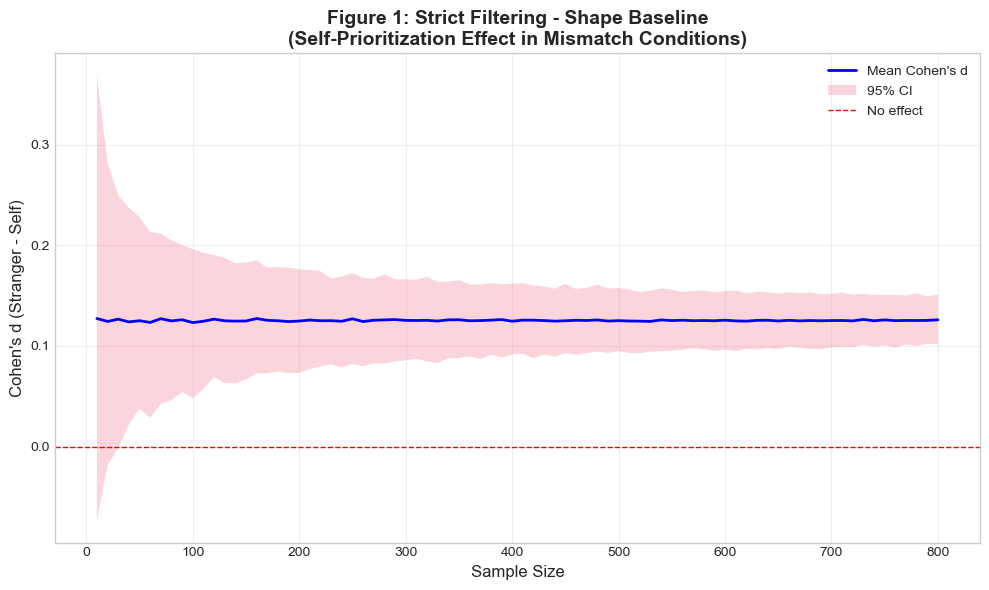

Figure 1 saved: figure1_shape_strict.png


In [12]:
# Generate Figure 1: Strict filtering - Shape baseline
fig, ax = plt.subplots(figsize=(10, 6))

data = bootstrap_df[(bootstrap_df['Filtering'] == 'Strict') & 
                    (bootstrap_df['Baseline'] == 'Shape')]

ax.plot(data['Sample_Size'], data['Mean_Cohens_d'], 'b-', linewidth=2, label='Mean Cohen\'s d')
ax.fill_between(data['Sample_Size'], 
                data['CI_lower'], 
                data['CI_upper'], 
                alpha=0.3, label='95% CI')
ax.axhline(y=0, color='r', linestyle='--', linewidth=1, label='No effect')

ax.set_xlabel('Sample Size', fontsize=12)
ax.set_ylabel('Cohen\'s d (Stranger - Self)', fontsize=12)
ax.set_title('Figure 1: Strict Filtering - Shape Baseline\n(Self-Prioritization Effect in Mismatch Conditions)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_path / 'figure1_shape_strict.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 1 saved: figure1_shape_strict.png")

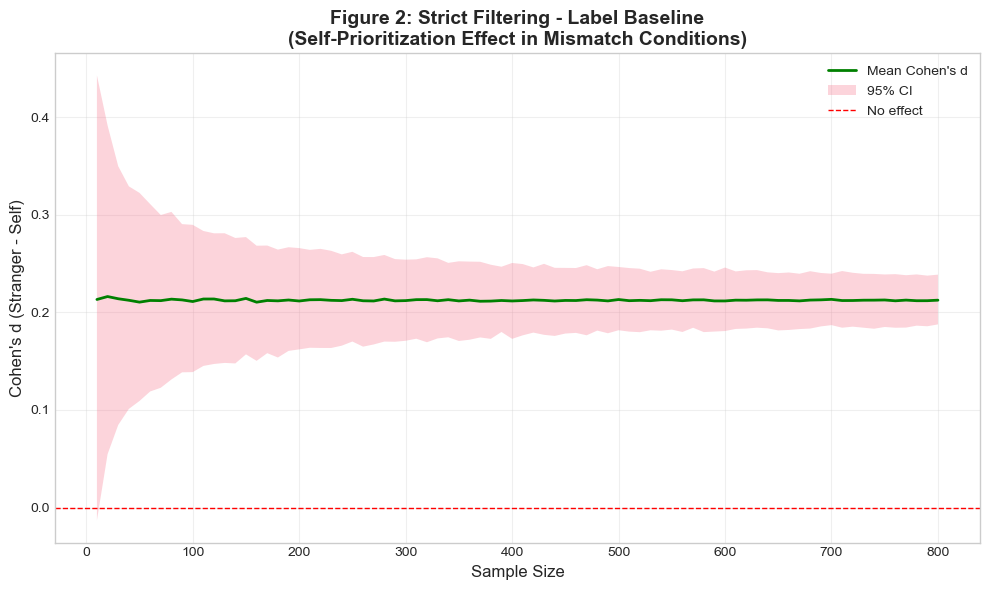

Figure 2 saved: figure2_label_strict.png


In [13]:
# Generate Figure 2: Strict filtering - Label baseline
fig, ax = plt.subplots(figsize=(10, 6))

data = bootstrap_df[(bootstrap_df['Filtering'] == 'Strict') & 
                    (bootstrap_df['Baseline'] == 'Label')]

ax.plot(data['Sample_Size'], data['Mean_Cohens_d'], 'g-', linewidth=2, label='Mean Cohen\'s d')
ax.fill_between(data['Sample_Size'], 
                data['CI_lower'], 
                data['CI_upper'], 
                alpha=0.3, label='95% CI')
ax.axhline(y=0, color='r', linestyle='--', linewidth=1, label='No effect')

ax.set_xlabel('Sample Size', fontsize=12)
ax.set_ylabel('Cohen\'s d (Stranger - Self)', fontsize=12)
ax.set_title('Figure 2: Strict Filtering - Label Baseline\n(Self-Prioritization Effect in Mismatch Conditions)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_path / 'figure2_label_strict.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 2 saved: figure2_label_strict.png")

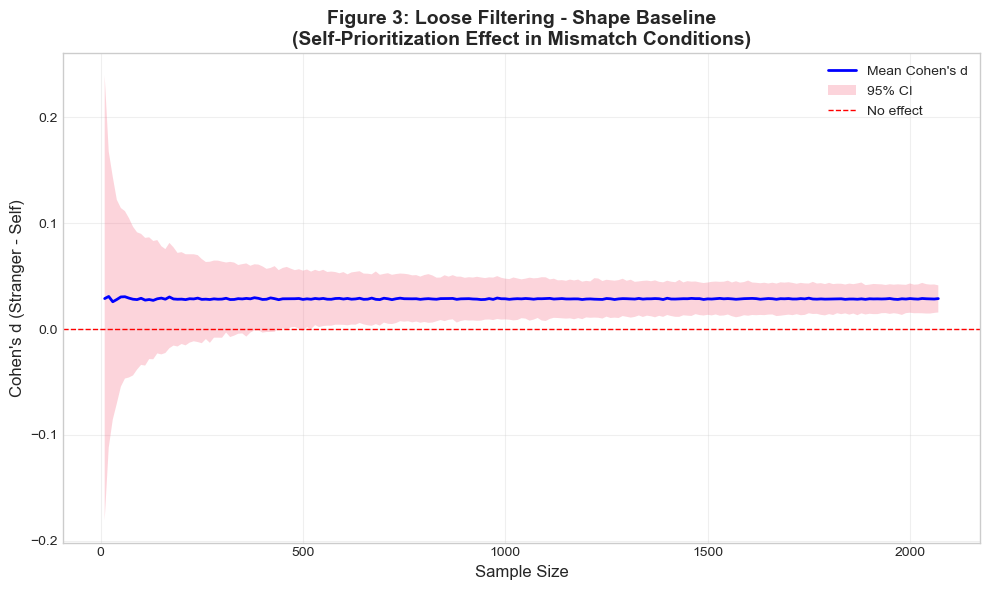

Figure 3 saved: figure3_shape_loose.png


In [14]:
# Generate Figure 3: Loose filtering - Shape baseline
fig, ax = plt.subplots(figsize=(10, 6))

data = bootstrap_df[(bootstrap_df['Filtering'] == 'Loose') & 
                    (bootstrap_df['Baseline'] == 'Shape')]

ax.plot(data['Sample_Size'], data['Mean_Cohens_d'], 'b-', linewidth=2, label='Mean Cohen\'s d')
ax.fill_between(data['Sample_Size'], 
                data['CI_lower'], 
                data['CI_upper'], 
                alpha=0.3, label='95% CI')
ax.axhline(y=0, color='r', linestyle='--', linewidth=1, label='No effect')

ax.set_xlabel('Sample Size', fontsize=12)
ax.set_ylabel('Cohen\'s d (Stranger - Self)', fontsize=12)
ax.set_title('Figure 3: Loose Filtering - Shape Baseline\n(Self-Prioritization Effect in Mismatch Conditions)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_path / 'figure3_shape_loose.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 3 saved: figure3_shape_loose.png")

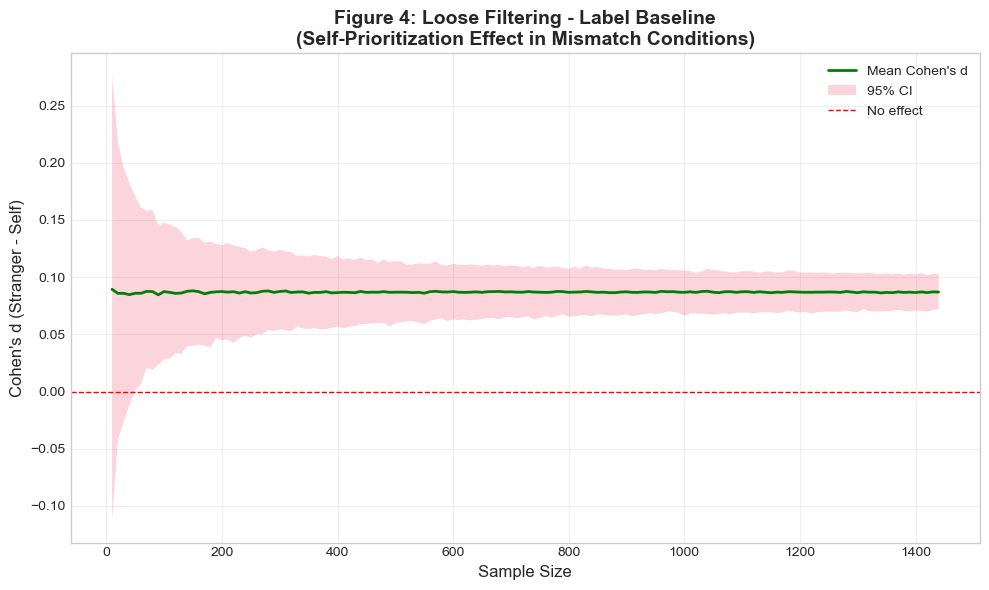

Figure 4 saved: figure4_label_loose.png


In [15]:
# Generate Figure 4: Loose filtering - Label baseline
fig, ax = plt.subplots(figsize=(10, 6))

data = bootstrap_df[(bootstrap_df['Filtering'] == 'Loose') & 
                    (bootstrap_df['Baseline'] == 'Label')]

ax.plot(data['Sample_Size'], data['Mean_Cohens_d'], 'g-', linewidth=2, label='Mean Cohen\'s d')
ax.fill_between(data['Sample_Size'], 
                data['CI_lower'], 
                data['CI_upper'], 
                alpha=0.3, label='95% CI')
ax.axhline(y=0, color='r', linestyle='--', linewidth=1, label='No effect')

ax.set_xlabel('Sample Size', fontsize=12)
ax.set_ylabel('Cohen\'s d (Stranger - Self)', fontsize=12)
ax.set_title('Figure 4: Loose Filtering - Label Baseline\n(Self-Prioritization Effect in Mismatch Conditions)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_path / 'figure4_label_loose.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 4 saved: figure4_label_loose.png")

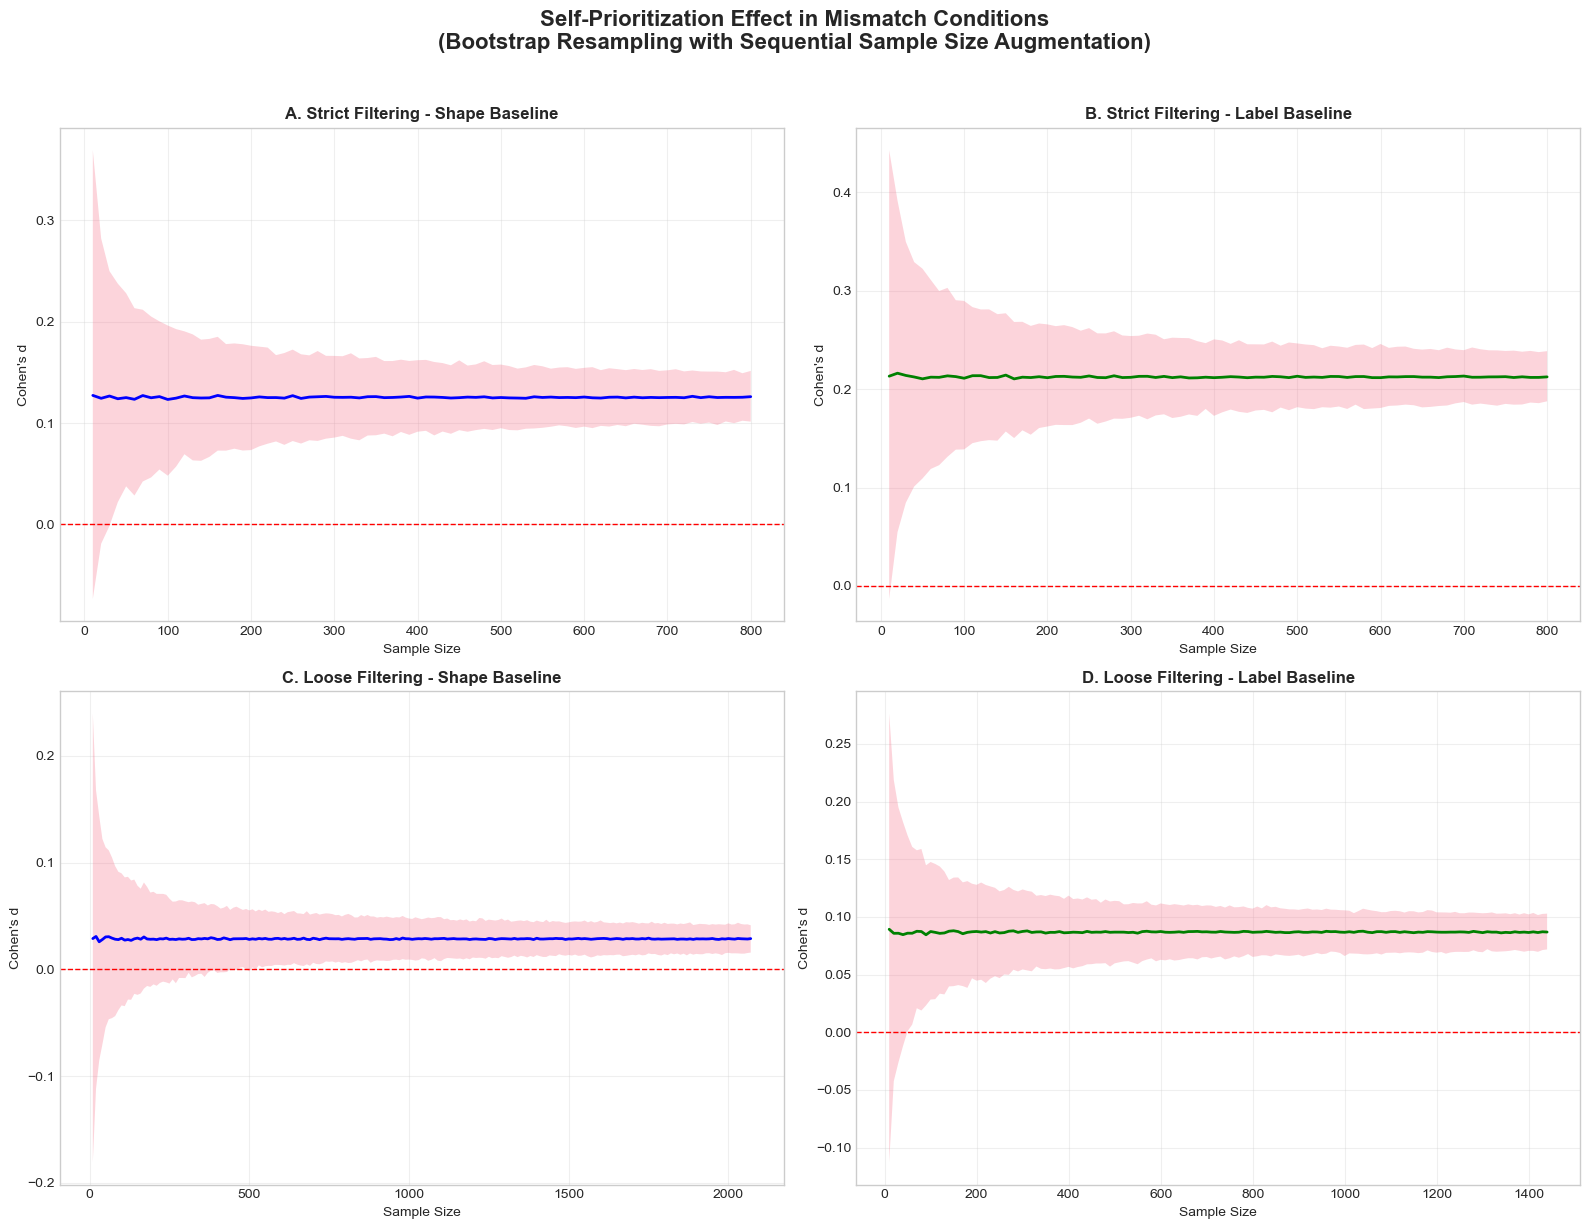

Combined figure saved: combined_figures_300dpi.png


In [16]:
# Combine 4 figures into a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Figure 1: Strict - Shape
ax1 = axes[0, 0]
data1 = bootstrap_df[(bootstrap_df['Filtering'] == 'Strict') & 
                     (bootstrap_df['Baseline'] == 'Shape')]
ax1.plot(data1['Sample_Size'], data1['Mean_Cohens_d'], 'b-', linewidth=2)
ax1.fill_between(data1['Sample_Size'], data1['CI_lower'], data1['CI_upper'], alpha=0.3)
ax1.axhline(y=0, color='r', linestyle='--', linewidth=1)
ax1.set_xlabel('Sample Size', fontsize=10)
ax1.set_ylabel('Cohen\'s d', fontsize=10)
ax1.set_title('A. Strict Filtering - Shape Baseline', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Figure 2: Strict - Label
ax2 = axes[0, 1]
data2 = bootstrap_df[(bootstrap_df['Filtering'] == 'Strict') & 
                     (bootstrap_df['Baseline'] == 'Label')]
ax2.plot(data2['Sample_Size'], data2['Mean_Cohens_d'], 'g-', linewidth=2)
ax2.fill_between(data2['Sample_Size'], data2['CI_lower'], data2['CI_upper'], alpha=0.3)
ax2.axhline(y=0, color='r', linestyle='--', linewidth=1)
ax2.set_xlabel('Sample Size', fontsize=10)
ax2.set_ylabel('Cohen\'s d', fontsize=10)
ax2.set_title('B. Strict Filtering - Label Baseline', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Figure 3: Loose - Shape
ax3 = axes[1, 0]
data3 = bootstrap_df[(bootstrap_df['Filtering'] == 'Loose') & 
                     (bootstrap_df['Baseline'] == 'Shape')]
ax3.plot(data3['Sample_Size'], data3['Mean_Cohens_d'], 'b-', linewidth=2)
ax3.fill_between(data3['Sample_Size'], data3['CI_lower'], data3['CI_upper'], alpha=0.3)
ax3.axhline(y=0, color='r', linestyle='--', linewidth=1)
ax3.set_xlabel('Sample Size', fontsize=10)
ax3.set_ylabel('Cohen\'s d', fontsize=10)
ax3.set_title('C. Loose Filtering - Shape Baseline', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Figure 4: Loose - Label
ax4 = axes[1, 1]
data4 = bootstrap_df[(bootstrap_df['Filtering'] == 'Loose') & 
                     (bootstrap_df['Baseline'] == 'Label')]
ax4.plot(data4['Sample_Size'], data4['Mean_Cohens_d'], 'g-', linewidth=2)
ax4.fill_between(data4['Sample_Size'], data4['CI_lower'], data4['CI_upper'], alpha=0.3)
ax4.axhline(y=0, color='r', linestyle='--', linewidth=1)
ax4.set_xlabel('Sample Size', fontsize=10)
ax4.set_ylabel('Cohen\'s d', fontsize=10)
ax4.set_title('D. Loose Filtering - Label Baseline', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# Add overall title
fig.suptitle('Self-Prioritization Effect in Mismatch Conditions\n(Bootstrap Resampling with Sequential Sample Size Augmentation)', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(output_path / 'combined_figures_300dpi.png', dpi=300, bbox_inches='tight')
plt.show()

print("Combined figure saved: combined_figures_300dpi.png")

In [17]:
# Generate summary statistics report
print("=" * 80)
print("ANALYSIS SUMMARY: Self-Prioritization Effect in Mismatch Conditions")
print("=" * 80)

print("\n1. DATA OVERVIEW:")
print(f"   Total datasets loaded: {len(clean_files)}")
print(f"   Total mismatch trials: {len(mismatch_df)}")
print(f"   Unique participants: {mismatch_df['Subject'].nunique()}")

print("\n2. COHEN'S d CALCULATION:")
for filtering in ['Strict', 'Loose']:
    for baseline in ['Shape', 'Label']:
        subset = all_cohens_d[(all_cohens_d['Filtering'] == filtering) & 
                             (all_cohens_d['Baseline'] == baseline)]
        if len(subset) > 0:
            print(f"   {filtering} - {baseline}:")
            print(f"     Participants: {len(subset)}")
            print(f"     Mean Cohen's d: {subset['Cohens_d'].mean():.3f}")
            print(f"     SD: {subset['Cohens_d'].std():.3f}")
            print(f"     Range: [{subset['Cohens_d'].min():.3f}, {subset['Cohens_d'].max():.3f}]")

print("\n3. BOOTSTRAP RESULTS (Final Sample Size):")
for filtering in ['Strict', 'Loose']:
    for baseline in ['Shape', 'Label']:
        subset = bootstrap_df[(bootstrap_df['Filtering'] == filtering) & 
                             (bootstrap_df['Baseline'] == baseline)]
        if len(subset) > 0:
            final = subset.iloc[-1]
            print(f"   {filtering} - {baseline}:")
            print(f"     Final sample size: {final['Sample_Size']}")
            print(f"     Mean Cohen's d: {final['Mean_Cohens_d']:.3f}")
            print(f"     95% CI: [{final['CI_lower']:.3f}, {final['CI_upper']:.3f}]")
            print(f"     Significant: {'Yes' if final['CI_lower'] > 0 or final['CI_upper'] < 0 else 'No'}")

print("\n4. OUTPUT FILES:")
print(f"   - cohens_d_by_participant.csv")
print(f"   - bootstrap_results.csv")
print(f"   - figure1_shape_strict.png")
print(f"   - figure2_label_strict.png")
print(f"   - figure3_shape_loose.png")
print(f"   - figure4_label_loose.png")
print(f"   - combined_figures_300dpi.png")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)

ANALYSIS SUMMARY: Self-Prioritization Effect in Mismatch Conditions

1. DATA OVERVIEW:
   Total datasets loaded: 72
   Total mismatch trials: 853015
   Unique participants: 1676

2. COHEN'S d CALCULATION:
   Strict - Shape:
     Participants: 801
     Mean Cohen's d: 0.125
     SD: 0.363
     Range: [-1.109, 1.691]
   Strict - Label:
     Participants: 801
     Mean Cohen's d: 0.212
     SD: 0.378
     Range: [-0.894, 2.506]
   Loose - Shape:
     Participants: 2074
     Mean Cohen's d: 0.029
     SD: 0.319
     Range: [-1.300, 1.460]
   Loose - Label:
     Participants: 1441
     Mean Cohen's d: 0.087
     SD: 0.307
     Range: [-1.198, 1.481]

3. BOOTSTRAP RESULTS (Final Sample Size):
   Strict - Shape:
     Final sample size: 800
     Mean Cohen's d: 0.126
     95% CI: [0.101, 0.151]
     Significant: Yes
   Strict - Label:
     Final sample size: 800
     Mean Cohen's d: 0.212
     95% CI: [0.188, 0.239]
     Significant: Yes
   Loose - Shape:
     Final sample size: 2070
     Mean

## Methodology Notes

### Cohen's d Calculation
Cohen's d = (Mean_RT_Stranger - Mean_RT_Self) / Pooled_SD

Where:
- Pooled_SD = sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
- Positive d indicates Stranger RT > Self RT (self-prioritization effect)

### Data Filtering Criteria

**Strict Filtering (Figures 1-2)**:
- Requires both Shape and Label standardized identity columns
- Requires at least 3 different social identities per participant
- Excludes trials where Shape=Stranger & Label=Self (for Shape baseline)
- Excludes trials where Label=Stranger & Shape=Self (for Label baseline)
- This controls for potential self-relevance confounds

**Loose Filtering (Figures 3-4)**:
- Only requires Shape to be Self or Stranger
- No Label filtering required
- Simpler criterion, includes more data

### Bootstrap Resampling
- 1000 iterations per sample size
- Sample sizes: 10, 20, 30, ..., n_participants
- Resampling with replacement
- Calculates mean Cohen's d and 95% confidence interval

### References
- Sui, J., He, X., & Humphreys, G. W. (2012). Perceptual effects of self-relevance. Journal of Experimental Psychology: Human Perception and Performance, 38(5), 1105-1117.
- Cohen, J. (1988). Statistical Power Analysis for the Behavioral Sciences (2nd ed.). Lawrence Erlbaum Associates.
- Efron, B., & Tibshirani, R. J. (1993). An Introduction to the Bootstrap. Chapman & Hall.